# Station-MAE — Model Visualisation

Self-contained notebook for inspecting the trained (or randomly initialised) model:

1. **Architecture** — parameter breakdown by module and sub-module  
2. **LR schedule** — warmup → cosine decay curve  
3. **Embeddings** — spatial, temporal, and delta encoding  
4. **Inference** — run a val batch through the model  
5. **Scatter plots** — predicted vs. target for all 5 variables  
6. **Per-station RMSE** — which stations are hardest to reconstruct  
7. **Error by lead-time** — RMSE vs. Δt horizon  

**Set `DATA_ROOT` and optionally `CKPT_PATH` before running all cells.**

In [1]:
import sys, os, math
sys.path.insert(0, "..")   # makes Station MAE importable when run from subfolder

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from torch.utils.data import DataLoader, Subset

# ── User config ────────────────────────────────────────────────────────────
DATA_ROOT  = "/Users/aureliedejong/Documents/ETH/_DAS Project/PeakWeatherDataset"
CKPT_PATH  = None   # e.g. "checkpoints/full_run_local/best.ckpt" — None = random init

WINDOW_SIZE     = 12     # must match the checkpoint (12 × 10 min = 2 h)
MAX_DELTA_STEPS = 6      # max lead-time steps used when building dataset
D_MODEL         = 128
ENC_LAYERS      = 4
DEC_LAYERS      = 2
MASK_RATIO      = 0.5
BATCH_SIZE      = 16
N_BATCHES_EVAL  = 20     # number of val batches to collect for scatter / RMSE plots
N_DELTAS_EVAL   = 6      # lead-times to sweep for the horizon analysis

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() and torch.backends.mps.is_built() else
    "cpu"
)
print(f"Device : {device}")

# Colour palette used throughout
VAR_COLORS = ["#4477AA", "#EE6677", "#228833", "#CCBB44", "#AA3377"]

Device : mps


## 1 — Load dataset + build model

In [2]:
from data.dataset import (
    load_peakweather, build_spatial_features, StationMAEDataset,
    VARIABLE_NAMES, NUM_VARIABLES, TRAIN_YEARS,
)
from model.embeddings import TARGET_VARIABLE_NAMES, NUM_TARGET_VARIABLES
from model.mae import StationMAE

print("Loading PeakWeather …")
ds = load_peakweather(DATA_ROOT)
spatial, _ = build_spatial_features(ds)   # (N, 15)
N = spatial.shape[0]

print("Building val dataset …")
val_ds = StationMAEDataset(
    ds,
    window_size=WINDOW_SIZE,
    delta_steps=MAX_DELTA_STEPS,
    split="val",
    num_delta_per_sample=1,
    max_delta_steps=MAX_DELTA_STEPS,
    cache_dir=DATA_ROOT,
)
print(f"Val samples : {len(val_ds):,}  |  stations N={N}")

# ── Model ─────────────────────────────────────────────────────────────────
model = StationMAE(
    d_model=D_MODEL, enc_heads=4, enc_layers=ENC_LAYERS,
    dec_heads=4, dec_layers=DEC_LAYERS, mlp_ratio=4.0,
    dropout=0.0, mask_ratio=MASK_RATIO,
    factorised_encoder=True,
    encoder_spatial_attn=False,
    cross_attention_decoder=True,
)
print(f"\nModel built — {model.count_parameters():,} trainable parameters")

# ── Optionally load checkpoint ────────────────────────────────────────────
if CKPT_PATH and os.path.exists(CKPT_PATH):
    ckpt = torch.load(CKPT_PATH, map_location="cpu", weights_only=False)
    sd = {k[len("model."):]: v for k, v in ckpt["state_dict"].items()
          if k.startswith("model.")}
    model.load_state_dict(sd)
    print(f"Loaded checkpoint: {CKPT_PATH}  (epoch {ckpt.get('epoch', '?')})")
else:
    print("No checkpoint — using random initialisation (plots show untrained noise)")

model.to(device).eval()
print("Model ready.")

Loading PeakWeather …
Building val dataset …
[Cache] Loading from /Users/aureliedejong/Documents/ETH/_DAS Project/PeakWeatherDataset/peakweather_obs_cache.pt …
[Cache] Loaded in 0.8s  (obs (461952, 156, 6))
Val samples : 52,543  |  stations N=156

Model built — 1,466,885 trainable parameters
No checkpoint — using random initialisation (plots show untrained noise)
Model ready.


## 2 — Architecture: parameter breakdown

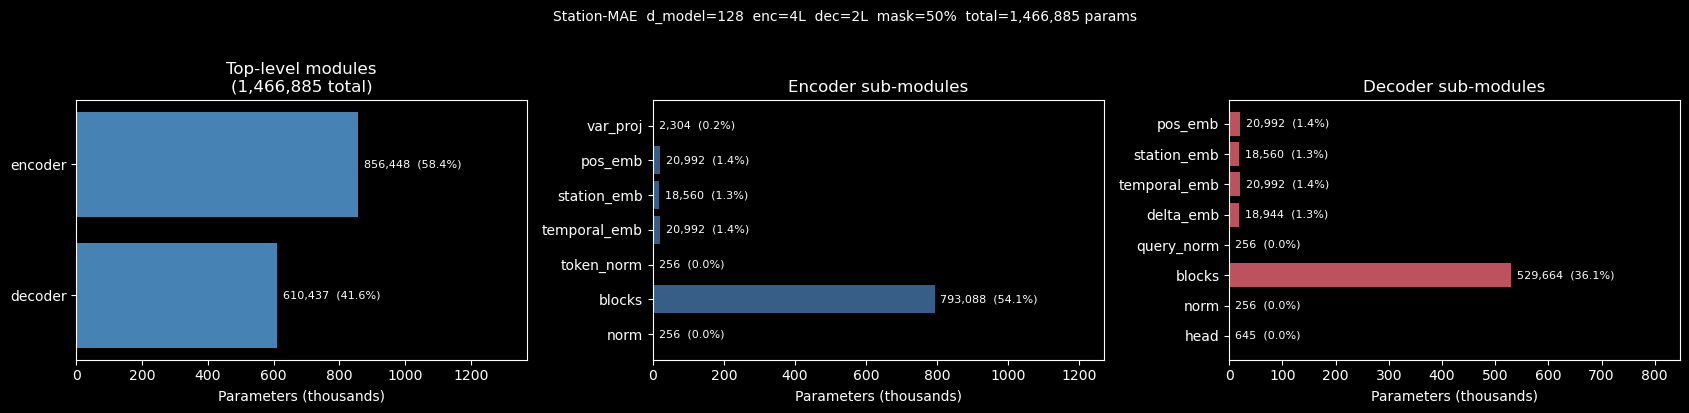


Module                             Params    % total
------------------------------------------------------
  encoder                         856,448      58.4%
  decoder                         610,437      41.6%
  TOTAL                         1,466,885     100.0%


In [3]:
# ── Top-level modules ─────────────────────────────────────────────────────
top_rows = []
for name, mod in model.named_children():
    p = sum(x.numel() for x in mod.parameters() if x.requires_grad)
    top_rows.append((name, p))

# ── Encoder sub-modules ───────────────────────────────────────────────────
enc_rows = []
for name, mod in model.encoder.named_children():
    p = sum(x.numel() for x in mod.parameters() if x.requires_grad)
    enc_rows.append((name, p))

# ── Decoder sub-modules ───────────────────────────────────────────────────
dec_rows = []
for name, mod in model.decoder.named_children():
    p = sum(x.numel() for x in mod.parameters() if x.requires_grad)
    dec_rows.append((name, p))

total = model.count_parameters()

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

def _hbar(ax, rows, title, color="steelblue", alpha=1.0):
    labels = [r[0] for r in rows]
    vals   = [r[1] for r in rows]
    if not vals:
        ax.set_title(title + "\n(empty)"); return
    bars = ax.barh(labels, [v / 1000 for v in vals], color=color, alpha=alpha)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_width() + max(vals) / 1000 * 0.02,
                bar.get_y() + bar.get_height() / 2,
                f"{v:,}  ({100*v/total:.1f}%)", va="center", fontsize=8)
    ax.set_xlabel("Parameters (thousands)")
    ax.set_xlim(0, max(vals) / 1000 * 1.6)
    ax.set_title(title)
    ax.invert_yaxis()

_hbar(axes[0], top_rows, f"Top-level modules\n({total:,} total)", "steelblue")
_hbar(axes[1], enc_rows, "Encoder sub-modules", "#4477AA", 0.8)
_hbar(axes[2], dec_rows, "Decoder sub-modules", "#EE6677", 0.8)

plt.suptitle(f"Station-MAE  d_model={D_MODEL}  enc={ENC_LAYERS}L  dec={DEC_LAYERS}L  "
             f"mask={MASK_RATIO:.0%}  total={total:,} params",
             fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

print(f"\n{'Module':<30} {'Params':>10}   {'% total':>8}")
print("-" * 54)
for name, p in top_rows:
    print(f"  {name:<28} {p:>10,}   {100*p/total:>7.1f}%")
print(f"  {'TOTAL':<28} {total:>10,}   {'100.0%':>8}")

## 3 — LR schedule: warmup → cosine → min_lr floor

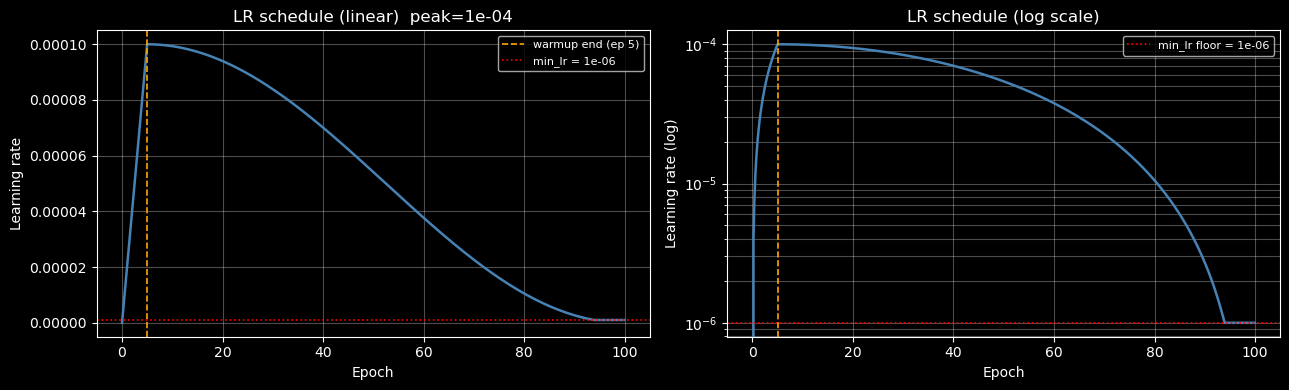

Peak LR     : 1.0e-04   |  Warmup: 5 epochs = 32,810 steps
Min LR floor: 1.0e-06   |  Ratio to peak: 0.0100
Total steps : 656,200   |  ~6562 steps/epoch


In [4]:
# Visualise the LR schedule without running any training.
# Change these to match your actual run script values.
LR_PEAK      = 1e-4
LR_MIN       = 1e-6      # --min_lr
EPOCHS       = 100
WARMUP_EP    = 5
STEPS_PER_EP = 6562      # example: ~105K samples / batch_size 16

total_steps  = EPOCHS * STEPS_PER_EP
warmup_steps = WARMUP_EP * STEPS_PER_EP
min_ratio    = LR_MIN / LR_PEAK

def lr_at_step(step):
    if step < warmup_steps:
        return LR_PEAK * step / max(warmup_steps, 1)
    progress = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
    return LR_PEAK * max(cosine, min_ratio)

steps = np.arange(0, total_steps + 1, total_steps // 500)
lrs   = [lr_at_step(s) for s in steps]
epoch_axis = steps / STEPS_PER_EP

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Linear scale
ax = axes[0]
ax.plot(epoch_axis, lrs, color="steelblue", linewidth=1.8)
ax.axvline(WARMUP_EP, color="orange", linestyle="--", linewidth=1.2, label=f"warmup end (ep {WARMUP_EP})")
ax.axhline(LR_MIN,    color="red",    linestyle=":",  linewidth=1.2, label=f"min_lr = {LR_MIN:.0e}")
ax.set_xlabel("Epoch"); ax.set_ylabel("Learning rate")
ax.set_title(f"LR schedule (linear)  peak={LR_PEAK:.0e}")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Log scale — easier to see the floor
ax2 = axes[1]
ax2.semilogy(epoch_axis, lrs, color="steelblue", linewidth=1.8)
ax2.axvline(WARMUP_EP, color="orange", linestyle="--", linewidth=1.2)
ax2.axhline(LR_MIN,    color="red",    linestyle=":",  linewidth=1.2,
            label=f"min_lr floor = {LR_MIN:.0e}")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Learning rate (log)")
ax2.set_title("LR schedule (log scale)")
ax2.legend(fontsize=8); ax2.grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()
print(f"Peak LR     : {LR_PEAK:.1e}   |  Warmup: {WARMUP_EP} epochs = {warmup_steps:,} steps")
print(f"Min LR floor: {LR_MIN:.1e}   |  Ratio to peak: {min_ratio:.4f}")
print(f"Total steps : {total_steps:,}   |  ~{STEPS_PER_EP} steps/epoch")

## 4 — Collect predictions on the validation set

In [5]:
val_loader = DataLoader(
    Subset(val_ds, list(range(min(N_BATCHES_EVAL * BATCH_SIZE, len(val_ds))))),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
)

all_preds   = []   # (B, N, V)
all_targets = []   # (B, N, V)
all_masks   = []   # (B, N, V)  bool
all_masked_idx = []  # (B, N_masked) — stations the encoder never saw

model.eval()
with torch.no_grad():
    for batch in val_loader:
        sp = batch["spatial"][0].to(device)   # (N, 15)
        loss, preds, masked_idx = model(
            batch["x"].to(device),
            batch["x_mask"].to(device),
            sp,
            batch["x_hours"].to(device),
            batch["y"].to(device),
            batch["y_mask"].to(device),
            batch["y_hours"].to(device),
            batch["delta_steps"].to(device),
        )
        all_preds.append(preds.cpu())          # (B, N, num_target_vars)
        all_targets.append(batch["y"][:, :, :NUM_TARGET_VARIABLES])   # (B, N, V_t)
        all_masks.append(batch["y_mask"][:, :, :NUM_TARGET_VARIABLES].bool())
        all_masked_idx.append(masked_idx.cpu())

# Stack into big tensors
P = torch.cat(all_preds,   dim=0)  # (total_B, N, V_t)
T = torch.cat(all_targets, dim=0)  # (total_B, N, V_t)
M = torch.cat(all_masks,   dim=0)  # (total_B, N, V_t)  bool

print(f"Collected  {P.shape[0]} samples  |  stations N={P.shape[1]}  "
      f"|  target vars={P.shape[2]}")

# Overall RMSE quick-check
pf = P[M]; tf = T[M]
overall_rmse = float((pf - tf).pow(2).mean().sqrt())
print(f"Overall RMSE (normalised space): {overall_rmse:.4f}")

Collected  320 samples  |  stations N=156  |  target vars=5
Overall RMSE (normalised space): 1.0803


## 5 — Scatter: predicted vs. target (all 5 variables)

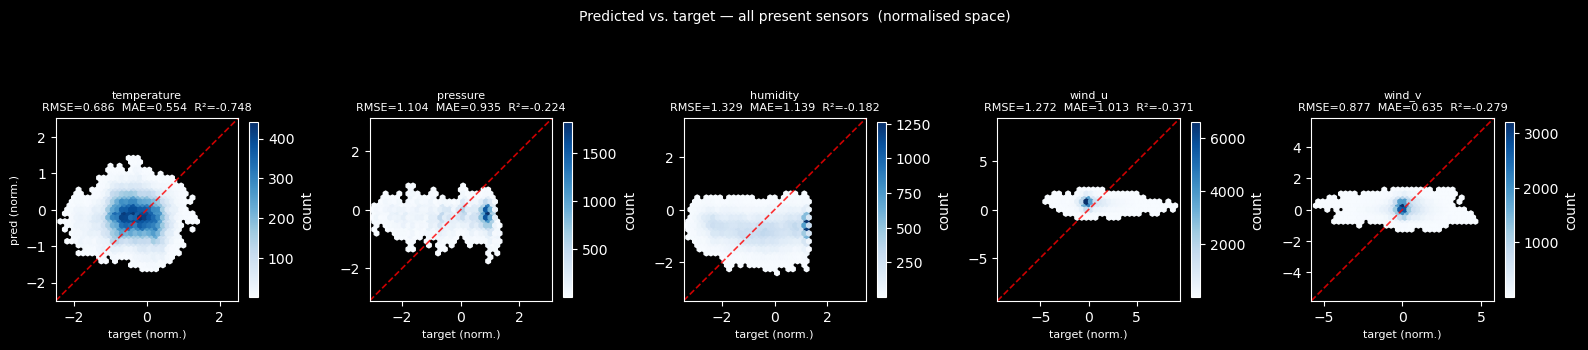

In [6]:
fig, axes = plt.subplots(1, NUM_TARGET_VARIABLES, figsize=(16, 3.5))

for v, (name, color) in enumerate(zip(TARGET_VARIABLE_NAMES, VAR_COLORS)):
    ax = axes[v]
    mv  = M[:, :, v].reshape(-1)               # flat boolean mask
    pv  = P[:, :, v].reshape(-1)[mv].numpy()   # predictions where sensor present
    tv  = T[:, :, v].reshape(-1)[mv].numpy()   # ground truth

    # Density-based scatter (hex-bin to avoid overplotting)
    lim = float(max(abs(tv).max(), abs(pv).max())) * 1.05
    hb  = ax.hexbin(tv, pv, gridsize=40, cmap="Blues", mincnt=1,
                    extent=[-lim, lim, -lim, lim])
    ax.plot([-lim, lim], [-lim, lim], "r--", linewidth=1.2, alpha=0.8, label="perfect")

    rmse = float(((pv - tv) ** 2).mean() ** 0.5)
    mae  = float(abs(pv - tv).mean())
    r2   = float(1 - ((pv - tv)**2).sum() / max(((tv - tv.mean())**2).sum(), 1e-8))

    ax.set_title(f"{name}\nRMSE={rmse:.3f}  MAE={mae:.3f}  R²={r2:.3f}", fontsize=8)
    ax.set_xlabel("target (norm.)", fontsize=8)
    ax.set_ylabel("pred (norm.)", fontsize=8) if v == 0 else None
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect("equal", adjustable="box")
    plt.colorbar(hb, ax=ax, shrink=0.6, label="count")

plt.suptitle("Predicted vs. target — all present sensors  (normalised space)",
             fontsize=10, y=1.03)
plt.tight_layout()
plt.show()

## 6 — Per-variable RMSE bar chart

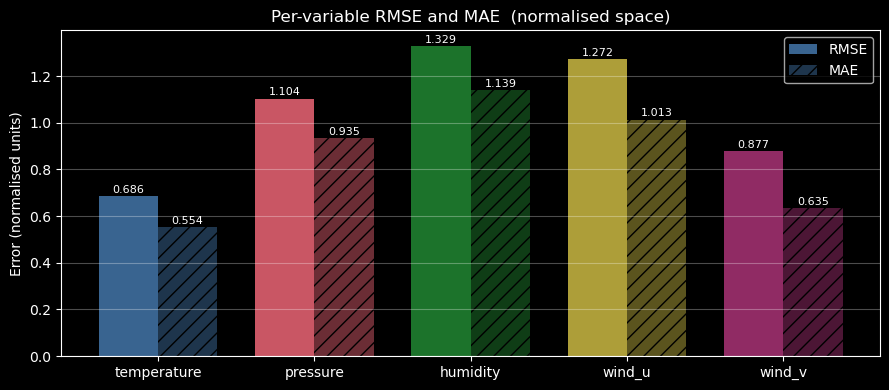

In [7]:
rmse_per_var = []
mae_per_var  = []
for v in range(NUM_TARGET_VARIABLES):
    mv = M[:, :, v].reshape(-1)
    pv = P[:, :, v].reshape(-1)[mv].numpy()
    tv = T[:, :, v].reshape(-1)[mv].numpy()
    rmse_per_var.append(float(((pv - tv)**2).mean()**0.5))
    mae_per_var.append(float(abs(pv - tv).mean()))

x = np.arange(NUM_TARGET_VARIABLES)
w = 0.38

fig, ax = plt.subplots(figsize=(9, 4))
bars1 = ax.bar(x - w/2, rmse_per_var, width=w, label="RMSE",
               color=VAR_COLORS, alpha=0.85)
bars2 = ax.bar(x + w/2, mae_per_var,  width=w, label="MAE",
               color=VAR_COLORS, alpha=0.45, hatch="//")

for bar, v in zip(bars1, rmse_per_var):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{v:.3f}", ha="center", va="bottom", fontsize=8)
for bar, v in zip(bars2, mae_per_var):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{v:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(TARGET_VARIABLE_NAMES)
ax.set_ylabel("Error (normalised units)")
ax.set_title("Per-variable RMSE and MAE  (normalised space)")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 7 — Per-station RMSE (which stations are hardest?)

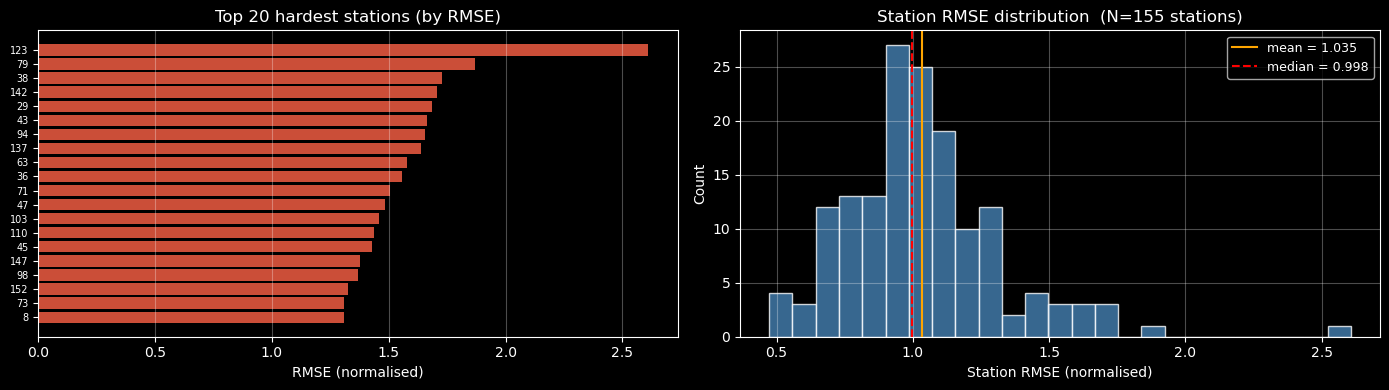

Station RMSE — mean 1.0350  median 0.9978  min 0.4728  max 2.6073


In [8]:
# Compute RMSE per station averaged over all val samples and all target variables.
station_rmse = np.full(N, np.nan)
for n in range(N):
    mv = M[:, n, :].reshape(-1)   # all samples × all vars for station n
    pv = P[:, n, :].reshape(-1)[mv].numpy()
    tv = T[:, n, :].reshape(-1)[mv].numpy()
    if mv.sum() > 0:
        station_rmse[n] = float(((pv - tv)**2).mean()**0.5)

# Sort stations by RMSE
valid      = ~np.isnan(station_rmse)
sorted_idx = np.argsort(station_rmse[valid])[::-1]   # worst → best
sorted_rmse = station_rmse[valid][sorted_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart — top 20 worst stations
ax = axes[0]
top_k = min(20, len(sorted_idx))
ax.barh(range(top_k), sorted_rmse[:top_k][::-1],
        color="tomato", alpha=0.8)
ax.set_yticks(range(top_k))
ax.set_yticklabels([str(sorted_idx[i]) for i in range(top_k - 1, -1, -1)], fontsize=7)
ax.set_xlabel("RMSE (normalised)")
ax.set_title(f"Top {top_k} hardest stations (by RMSE)")
ax.grid(axis="x", alpha=0.3)

# Distribution of station RMSE
ax2 = axes[1]
ax2.hist(station_rmse[valid], bins=25, color="steelblue", alpha=0.8, edgecolor="white")
ax2.axvline(np.nanmean(station_rmse), color="orange", linewidth=1.5,
            label=f"mean = {np.nanmean(station_rmse):.3f}")
ax2.axvline(np.nanmedian(station_rmse), color="red", linewidth=1.5, linestyle="--",
            label=f"median = {np.nanmedian(station_rmse):.3f}")
ax2.set_xlabel("Station RMSE (normalised)"); ax2.set_ylabel("Count")
ax2.set_title(f"Station RMSE distribution  (N={valid.sum()} stations)")
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Station RMSE — mean {np.nanmean(station_rmse):.4f}  "
      f"median {np.nanmedian(station_rmse):.4f}  "
      f"min {np.nanmin(station_rmse):.4f}  "
      f"max {np.nanmax(station_rmse):.4f}")

## 8 — RMSE vs. lead-time Δt (how skill degrades with horizon)

In [9]:
# Build a dataset where delta_steps varies from 1 to N_DELTAS_EVAL.
# We reuse the same window samples but force a specific delta.

from data.dataset import StationMAEDataset

delta_rmse = {}   # {delta_steps: {var: rmse, 'overall': rmse}}

n_samples_horizon = min(256, len(val_ds))
horizon_subset    = Subset(val_ds, list(range(n_samples_horizon)))
horizon_loader    = DataLoader(horizon_subset, batch_size=BATCH_SIZE,
                               shuffle=False, num_workers=0)

for target_delta in range(1, N_DELTAS_EVAL + 1):
    p_list, t_list, m_list = [], [], []
    model.eval()
    with torch.no_grad():
        for batch in horizon_loader:
            sp = batch["spatial"][0].to(device)
            # Override delta_steps to the fixed target horizon
            B  = batch["x"].shape[0]
            ds_fixed = torch.full((B,), target_delta, dtype=torch.long).to(device)
            # y and y_mask from original batch (we only need the mask shape)
            y_b  = batch["y"].to(device)
            ym_b = batch["y_mask"].to(device)
            yh_b = batch["y_hours"].to(device)

            _, preds_h, _ = model(
                batch["x"].to(device), batch["x_mask"].to(device),
                sp, batch["x_hours"].to(device),
                y_b, ym_b, yh_b, ds_fixed,
            )
            p_list.append(preds_h.cpu())
            t_list.append(y_b[:, :, :NUM_TARGET_VARIABLES].cpu())
            m_list.append(ym_b[:, :, :NUM_TARGET_VARIABLES].bool().cpu())

    Pd = torch.cat(p_list); Td = torch.cat(t_list); Md = torch.cat(m_list)
    row = {}
    for v, vname in enumerate(TARGET_VARIABLE_NAMES):
        mv = Md[:, :, v].reshape(-1)
        pv = Pd[:, :, v].reshape(-1)[mv]; tv = Td[:, :, v].reshape(-1)[mv]
        row[vname] = float(((pv - tv)**2).mean()**0.5) if mv.sum() > 0 else float("nan")
    pf = Pd[Md]; tf = Td[Md]
    row["overall"] = float(((pf - tf)**2).mean()**0.5) if Md.sum() > 0 else float("nan")
    delta_rmse[target_delta] = row
    print(f"  Δt={target_delta:2d} ({target_delta*10} min)  overall RMSE = {row['overall']:.4f}")

print("\nDone.")

  Δt= 1 (10 min)  overall RMSE = 1.0929
  Δt= 2 (20 min)  overall RMSE = 1.0829
  Δt= 3 (30 min)  overall RMSE = 1.0912
  Δt= 4 (40 min)  overall RMSE = 1.0752
  Δt= 5 (50 min)  overall RMSE = 1.0862
  Δt= 6 (60 min)  overall RMSE = 1.0709

Done.


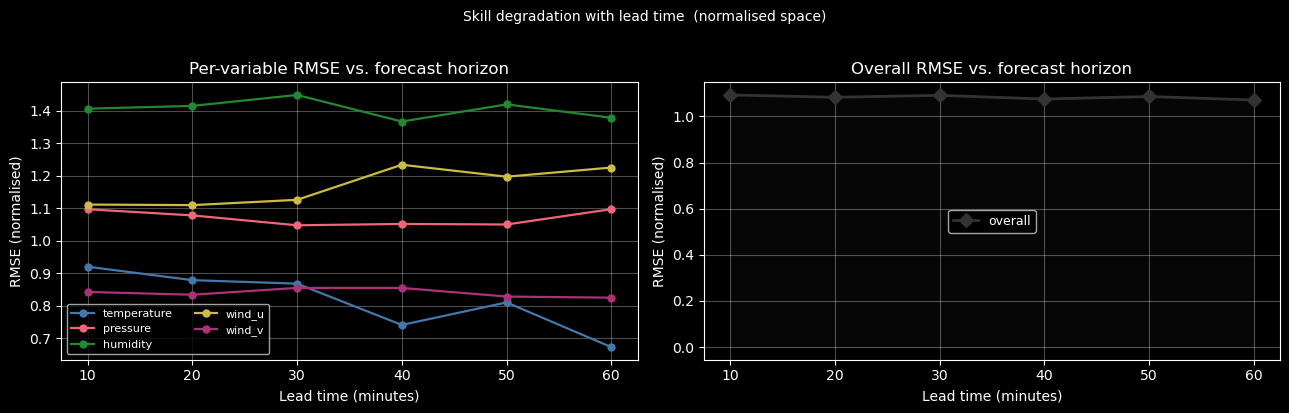

In [10]:
deltas      = sorted(delta_rmse.keys())
delta_mins  = [d * 10 for d in deltas]   # convert steps → minutes

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Per-variable RMSE vs. horizon
ax = axes[0]
for v, (vname, color) in enumerate(zip(TARGET_VARIABLE_NAMES, VAR_COLORS)):
    y_vals = [delta_rmse[d][vname] for d in deltas]
    ax.plot(delta_mins, y_vals, "o-", color=color, label=vname,
            linewidth=1.6, markersize=5)
ax.set_xlabel("Lead time (minutes)")
ax.set_ylabel("RMSE (normalised)")
ax.set_title("Per-variable RMSE vs. forecast horizon")
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
ax.set_xticks(delta_mins)

# Overall RMSE vs. horizon
ax2 = axes[1]
overall_vals = [delta_rmse[d]["overall"] for d in deltas]
ax2.plot(delta_mins, overall_vals, "D-", color="#333333",
         linewidth=2.0, markersize=7, label="overall")
ax2.fill_between(delta_mins, overall_vals, alpha=0.12, color="#333333")
ax2.set_xlabel("Lead time (minutes)")
ax2.set_ylabel("RMSE (normalised)")
ax2.set_title("Overall RMSE vs. forecast horizon")
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
ax2.set_xticks(delta_mins)

plt.suptitle("Skill degradation with lead time  (normalised space)",
             fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

## 9 — Spatial & temporal embeddings

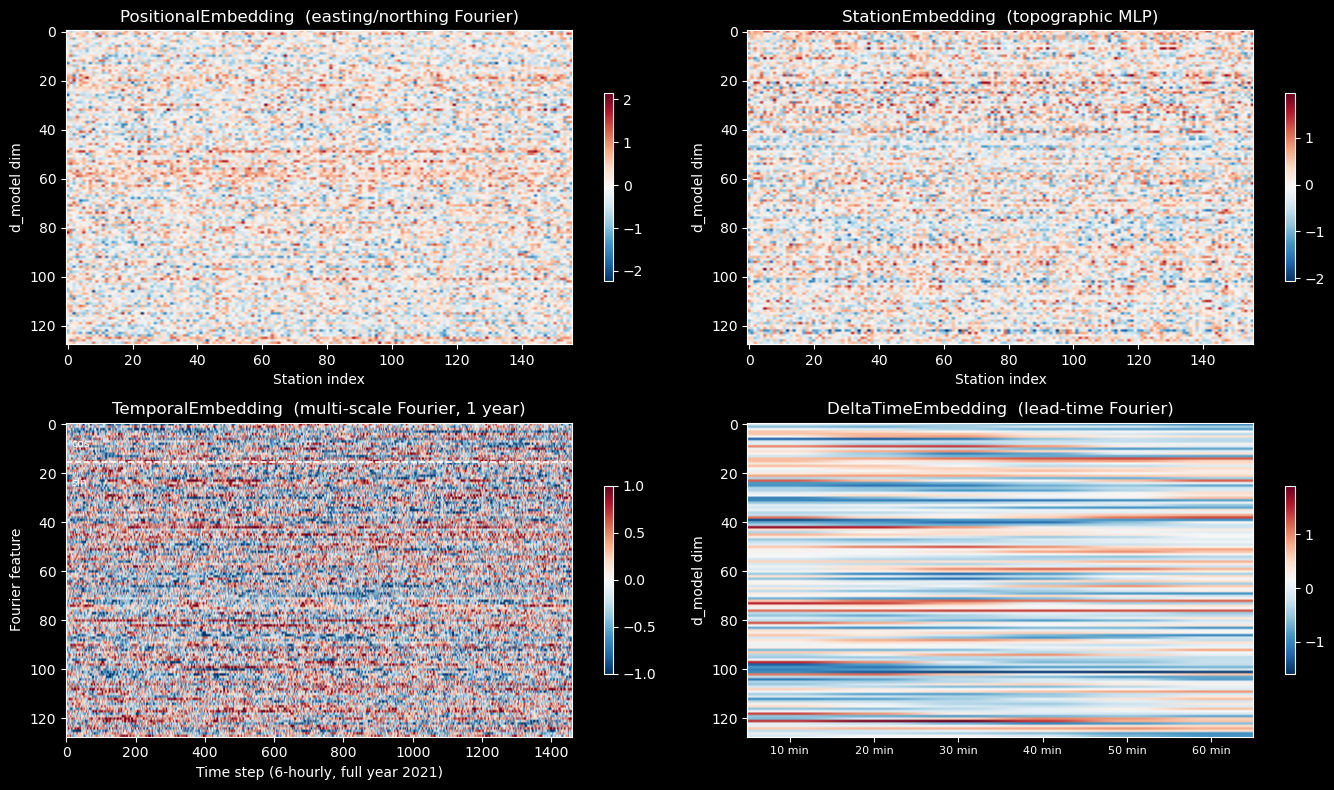

In [11]:
import pandas as pd
from model.embeddings import (
    encode_temporal,
    TEMPORAL_FOURIER_DIM, DELTA_FOURIER_DIM,
    POSITION_FOURIER_DIM, STATION_CHAR_DIM,
)

# Pull embedding sub-modules directly from the loaded model
# (they are already on `device` — we must move all inputs there too)
pos_emb      = model.encoder.pos_emb
station_emb  = model.encoder.station_emb
temporal_emb = model.encoder.temporal_emb
delta_emb    = getattr(model.decoder, "delta_emb", None)

# ── Move inputs to the same device as the model ──────────────────────────
sp_dev = spatial.unsqueeze(0).to(device)   # (1, N, 15)

with torch.no_grad():
    p1 = pos_emb(sp_dev[..., :2])          # (1, N, d_model)  easting/northing
    p2 = station_emb(sp_dev[..., 2:])      # (1, N, d_model)  characteristics

    # Temporal embedding over a full year sampled every 6 h
    start   = pd.Timestamp("2021-01-01 00:00:00+00:00")
    n_steps = 365 * 4
    times   = [start + pd.Timedelta(hours=6 * i) for i in range(n_steps)]
    h_arr   = torch.tensor([encode_temporal(ts) for ts in times]).to(device)  # on device
    tp_full = temporal_emb(h_arr.unsqueeze(0))   # (1, n_steps, d_model)

    # Delta-time embedding: Δt from 10 min to MAX_DELTA_STEPS × 10 min
    if delta_emb is not None:
        delta_hours = (torch.arange(1, MAX_DELTA_STEPS + 1, dtype=torch.float32)
                       * (10.0 / 60.0)).to(device)           # on device
        de_out = delta_emb(delta_hours.unsqueeze(0))          # (1, n_delta, d_model)

# Move outputs back to CPU for numpy/matplotlib
p1      = p1.cpu()
p2      = p2.cpu()
tp_full = tp_full.cpu()
if delta_emb is not None:
    de_out = de_out.cpu()

n_wl = TEMPORAL_FOURIER_DIM // 2

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Positional (easting/northing Fourier)
ax = axes[0, 0]
im = ax.imshow(p1[0].numpy().T, aspect="auto", cmap="RdBu_r")
ax.set_xlabel("Station index"); ax.set_ylabel("d_model dim")
ax.set_title("PositionalEmbedding  (easting/northing Fourier)")
plt.colorbar(im, ax=ax, shrink=0.6)

# Station characteristics (MLP)
ax = axes[0, 1]
im = ax.imshow(p2[0].numpy().T, aspect="auto", cmap="RdBu_r")
ax.set_xlabel("Station index"); ax.set_ylabel("d_model dim")
ax.set_title("StationEmbedding  (topographic MLP)")
plt.colorbar(im, ax=ax, shrink=0.6)

# Temporal Fourier over 1 year
ax = axes[1, 0]
im = ax.imshow(tp_full[0].numpy().T, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
ax.axhline(n_wl - 0.5, color="white", linewidth=1.2, linestyle="--")
ax.text(n_steps * 0.01, n_wl * 0.5,        "cos", color="white", fontsize=8, va="center")
ax.text(n_steps * 0.01, n_wl + n_wl * 0.5, "sin", color="white", fontsize=8, va="center")
ax.set_xlabel("Time step (6-hourly, full year 2021)")
ax.set_ylabel("Fourier feature")
ax.set_title("TemporalEmbedding  (multi-scale Fourier, 1 year)")
plt.colorbar(im, ax=ax, shrink=0.6)

# Delta-time embedding
ax = axes[1, 1]
if delta_emb is not None:
    im = ax.imshow(de_out[0].numpy().T, aspect="auto", cmap="RdBu_r")
    ax.set_xticks(range(MAX_DELTA_STEPS))
    ax.set_xticklabels([f"{int(d*10)} min" for d in range(1, MAX_DELTA_STEPS + 1)], fontsize=8)
    ax.set_ylabel("d_model dim")
    ax.set_title("DeltaTimeEmbedding  (lead-time Fourier)")
    plt.colorbar(im, ax=ax, shrink=0.6)
else:
    ax.text(0.5, 0.5, "delta_emb not found on decoder",
            ha="center", va="center", transform=ax.transAxes)
    ax.set_title("DeltaTimeEmbedding")

plt.tight_layout()
plt.show()


## 10 — Masked vs. visible station error

The encoder never sees masked stations — they are reconstructed purely from spatial context.
This cell compares the error on **masked** stations (the hard task) vs. **visible** stations.

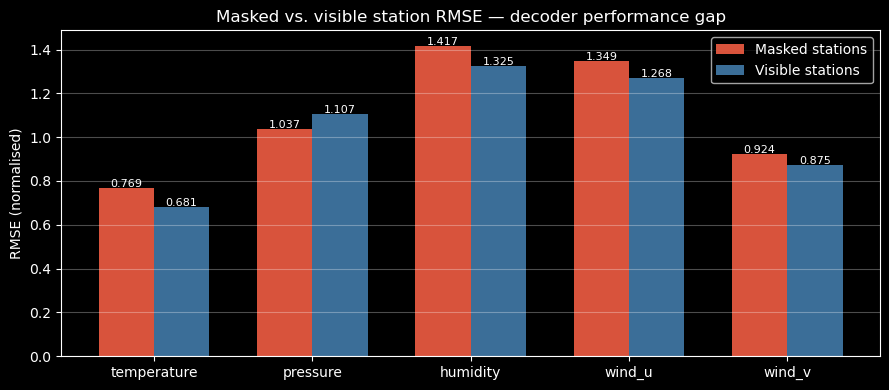


Variable           Masked RMSE   Visible RMSE       Gap
-------------------------------------------------------
  temperature           0.7694         0.6809   +0.0885
  pressure              1.0368         1.1071   -0.0703
  humidity              1.4171         1.3246   +0.0925
  wind_u                1.3491         1.2680   +0.0811
  wind_v                0.9236         0.8746   +0.0490


In [12]:
# Re-run inference but track which stations were masked in each batch.
# already have: all_preds (P), all_targets (T), all_masks (M), all_masked_idx

total_B = P.shape[0]
N_total = P.shape[1]

# For each sample, flag each station as masked or visible
was_masked = torch.zeros(total_B, N_total, dtype=torch.bool)
for b, mi in enumerate(all_masked_idx):
    # mi is (B_i, N_masked) — handle the batch dimension
    offset = 0
    if mi.dim() == 2:                       # batched from DataLoader
        for bi in range(mi.shape[0]):
            global_b = offset + bi
            if global_b < total_B:
                was_masked[global_b, mi[bi]] = True
        offset += mi.shape[0]

masked_rmse_per_var  = []
visible_rmse_per_var = []

for v in range(NUM_TARGET_VARIABLES):
    mv = M[:, :, v]                      # (B, N) bool — sensor present
    # Masked stations
    mask_flag = was_masked & mv          # present AND encoder-masked
    vis_flag  = (~was_masked) & mv       # present AND encoder-visible

    def _rmse(flag):
        pv = P[:, :, v][flag]; tv = T[:, :, v][flag]
        return float(((pv - tv)**2).mean()**0.5) if flag.sum() > 0 else float("nan")

    masked_rmse_per_var.append(_rmse(mask_flag))
    visible_rmse_per_var.append(_rmse(vis_flag))

x = np.arange(NUM_TARGET_VARIABLES)
w = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
bars1 = ax.bar(x - w/2, masked_rmse_per_var,  width=w, label="Masked stations",
               color="tomato",    alpha=0.85)
bars2 = ax.bar(x + w/2, visible_rmse_per_var, width=w, label="Visible stations",
               color="steelblue", alpha=0.85)

for bar, v in zip(bars1, masked_rmse_per_var):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{v:.3f}", ha="center", fontsize=8)
for bar, v in zip(bars2, visible_rmse_per_var):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{v:.3f}", ha="center", fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(TARGET_VARIABLE_NAMES)
ax.set_ylabel("RMSE (normalised)")
ax.set_title("Masked vs. visible station RMSE — decoder performance gap")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n{'Variable':<16}  {'Masked RMSE':>12}  {'Visible RMSE':>13}  {'Gap':>8}")
print("-" * 55)
for v, name in enumerate(TARGET_VARIABLE_NAMES):
    mr = masked_rmse_per_var[v]; vr = visible_rmse_per_var[v]
    gap = mr - vr if not (np.isnan(mr) or np.isnan(vr)) else float("nan")
    print(f"  {name:<14}  {mr:>12.4f}  {vr:>13.4f}  {gap:>+8.4f}")

## 11 — Per-station RMSE on the Swiss map (physical units)

Variable         σ (obs_std)     mean RMSE    unit
--------------------------------------------------
  temperature         8.7950        5.6788      °C
  pressure           82.1194       78.9740     hPa
  humidity           20.3312       25.6234       %
  wind_u              2.6272        3.0109     m/s
  wind_v              2.5150        1.9164     m/s


/var/folders/c_/b5jrks113nv2x0l4whxwz1cr0000gn/T/ipykernel_15463/2212598469.py:30: RuntimeWarning: Mean of empty slice
  rmse_overall = np.nanmean(rmse_norm, axis=1)   # (N,) — normalised space mean


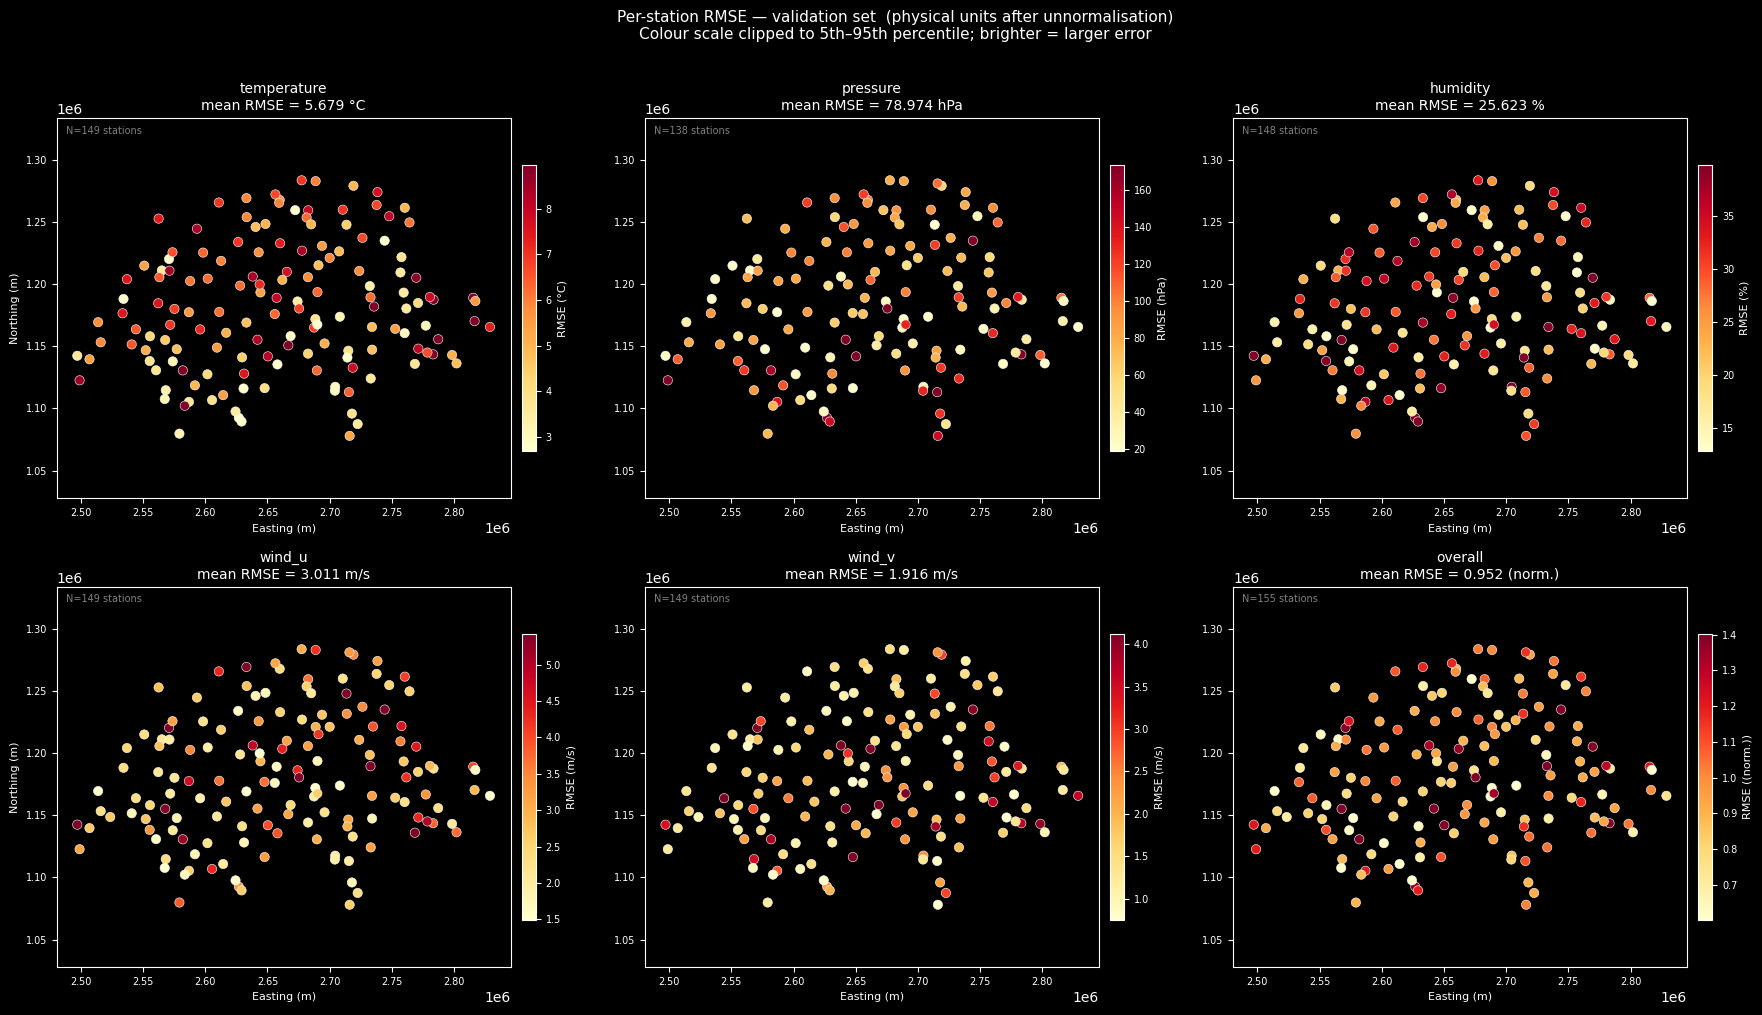


Top 10 worst stations (by normalised overall RMSE):
#     Station                                  E           N   RMSE(norm)
------------------------------------------------------------------------
1     station_110                        2699401     1248165          nan
2     station_124                        2744188     1234920       2.0880
3     station_79                         2641939     1155287       1.7333
4     station_38                         2783155     1143524       1.6486
5     station_43                         2581913     1130622       1.6265
6     station_143                        2675413     1180411       1.5498
7     station_94                         2567718     1155077       1.4751
8     station_29                         2570846     1220158       1.4254
9     station_47                         2650279     1141896       1.4033
10    station_36                         2732824     1189377       1.4001


In [13]:
# ── Station coordinates (LV95 Swiss projection, metres) ──────────────────
# ds.stations_table rows are in the same order as the N dimension in obs/P/T/M
stns  = ds.stations_table.reset_index()
east  = stns["swiss_easting"].values.astype(float)    # (N,)
north = stns["swiss_northing"].values.astype(float)   # (N,)

# ── Unnormalisation: obs_stats covers all 6 variables (target vars = first 5) ─
obs_std  = val_ds.obs_stats["std"].numpy()    # (6,)
obs_mean = val_ds.obs_stats["mean"].numpy()   # (6,) — kept for reference

# Physical units for each target variable (adjust if PeakWeather stores differently)
# Temperature: °C  |  Pressure: hPa  |  Humidity: %  |  Wind U/V: m/s
UNITS = ["°C", "hPa", "%", "m/s", "m/s"]

# ── Per-station, per-variable RMSE in normalised space ────────────────────
rmse_norm = np.full((N, NUM_TARGET_VARIABLES), np.nan)
for n in range(N):
    for v in range(NUM_TARGET_VARIABLES):
        mv = M[:, n, v]
        if mv.sum() > 0:
            pv = P[:, n, v][mv].numpy()
            tv = T[:, n, v][mv].numpy()
            rmse_norm[n, v] = float(((pv - tv) ** 2).mean() ** 0.5)

# Unnormalise: RMSE_physical = RMSE_norm × σ_v   (σ in physical units)
rmse_phys = rmse_norm * obs_std[:NUM_TARGET_VARIABLES][np.newaxis, :]  # (N, 5)

# Overall per-station RMSE: average across present sensors in physical space,
# then normalise by each variable's σ so they contribute equally
rmse_overall = np.nanmean(rmse_norm, axis=1)   # (N,) — normalised space mean

# ── Print summary ─────────────────────────────────────────────────────────
print(f"{'Variable':<14}  {'σ (obs_std)':>12}  {'mean RMSE':>12}  {'unit':>6}")
print("-" * 50)
for v, (name, unit) in enumerate(zip(TARGET_VARIABLE_NAMES, UNITS)):
    print(f"  {name:<12}  {obs_std[v]:>12.4f}  "
          f"{np.nanmean(rmse_phys[:, v]):>12.4f}  {unit:>6}")

# ── Map: 2 rows × 3 cols — one panel per variable + overall ──────────────
LAYOUT = [
    (0, "temperature"), (1, "pressure"), (2, "humidity"),
    (3, "wind_u"),      (4, "wind_v"),   (None, "overall"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for ax_idx, (v_idx, label) in enumerate(LAYOUT):
    ax = axes_flat[ax_idx]

    if v_idx is None:
        # Overall RMSE in normalised space
        rmse_v = rmse_overall
        unit   = "(norm.)"
        cmap   = "YlOrRd"
    else:
        rmse_v = rmse_phys[:, v_idx]
        unit   = UNITS[v_idx]
        cmap   = "YlOrRd"

    valid = ~np.isnan(rmse_v)

    # Colour scale: clip at 5th–95th percentile to avoid single outliers
    # dominating the palette
    vmin = np.nanpercentile(rmse_v, 5)
    vmax = np.nanpercentile(rmse_v, 95)

    sc = ax.scatter(
        east[valid], north[valid],
        c=rmse_v[valid],
        cmap=cmap,
        s=45,
        edgecolors="white", linewidths=0.4,
        vmin=vmin, vmax=vmax,
        zorder=3,
    )
    cbar = plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.02)
    cbar.set_label(f"RMSE ({unit})", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    mean_v = float(np.nanmean(rmse_v))
    ax.set_title(f"{label}\nmean RMSE = {mean_v:.3f} {unit}", fontsize=10)
    ax.set_xlabel("Easting (m)", fontsize=8)
    ax.set_ylabel("Northing (m)", fontsize=8) if ax_idx % 3 == 0 else None
    ax.tick_params(labelsize=7)
    ax.set_aspect("equal", adjustable="datalim")

    # Annotate N stations with data
    ax.text(0.02, 0.98, f"N={valid.sum()} stations",
            transform=ax.transAxes, fontsize=7,
            va="top", ha="left", color="grey")

plt.suptitle(
    "Per-station RMSE — validation set  (physical units after unnormalisation)\n"
    "Colour scale clipped to 5th–95th percentile; brighter = larger error",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.show()

# ── Worst 10 stations by overall normalised RMSE ─────────────────────────
worst_idx = np.argsort(rmse_overall)[::-1][:10]
print(f"\nTop 10 worst stations (by normalised overall RMSE):")
print(f"{'#':<4}  {'Station':<30}  {'E':>10}  {'N':>10}  {'RMSE(norm)':>11}")
print("-" * 72)
for rank, idx in enumerate(worst_idx, 1):
    stn_id = stns.iloc[idx]["abbr"] if "abbr" in stns.columns else str(idx)
    try:
        stn_name = stns.iloc[idx]["name"]
    except (KeyError, AttributeError):
        stn_name = f"station_{idx}"
    print(f"{rank:<4}  {str(stn_name):<30}  {east[idx]:>10.0f}  "
          f"{north[idx]:>10.0f}  {rmse_overall[idx]:>11.4f}")